# Model Comparison - v1 vs v2 on COVID-Period Data

Comparison framework:
  - v1 pre-COVID test : v1 on 2019-W46 to 2020-W11, sensing features only
  - v1 COVID-period test : v1 on 2021-W07 to 2021-W26, sensing features 
  - v2 COVID-period test : v2 on 2021-W07 to 2021-W26, all features

The first comparison (v1 pre-COVID vs v1 COVID-period) demonstrates drift. The second comparison (v1 COVID-period vs v2 COVID-period) demonstrates recovery. Both comparisons use models evaluated on data they never saw during training.

In [4]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../")))

import mlflow
import mlflow.lightgbm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import lightgbm as lgb

from src.features.feature_columns import SENSING_FEATURES, ALL_FEATURES, TARGET
from src.features.preprocessing import get_X_y
from src.models.train_v1 import load_v1_splits, fix_android_nan
from src.models.train_v2 import load_v2_splits

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("mental_health_prediction")
client = mlflow.tracking.MlflowClient()

PROJECT_ROOT = Path("../../")
SPLITS_DIR   = PROJECT_ROOT / "data" / "processed" / "splits"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"SENSING_FEATURES : {len(SENSING_FEATURES)}")
print(f"ALL_FEATURES     : {len(ALL_FEATURES)}")

Setup complete.
SENSING_FEATURES : 22
ALL_FEATURES     : 32


In [2]:
mlflow.set_tracking_uri("http://localhost:5000")
client = mlflow.tracking.MlflowClient()

for model_name in ["mental_health_v1"]:
    versions = client.search_model_versions(f"name='{model_name}'")
    for v in versions:
        print(f"Version : {v.version}")
        print(f"Run ID  : {v.run_id}")
        print(f"Source  : {v.source}")
        print(f"Status  : {v.status}")
        print()

Version : 5
Run ID  : 09a6e120b54b4b358cdb888b6951ed04
Source  : models:/m-47e1a1b85b6c46049876074c72c5671a
Status  : READY

Version : 4
Run ID  : 7e419b575fe449e686674abaf14e85fe
Source  : models:/m-0fff7ecfef064d06aa724411d8b7589c
Status  : READY

Version : 3
Run ID  : 81537046125b4fe580f7a822ff6ae824
Source  : models:/m-f5edc3ef48c548c893d8ef69cae61658
Status  : READY

Version : 2
Run ID  : b229f38d50bb41c48a5957e48fe0f364
Source  : models:/m-afcc524a0cbf419b8281965ae6f05af7
Status  : READY

Version : 1
Run ID  : b229f38d50bb41c48a5957e48fe0f364
Source  : models:/m-afcc524a0cbf419b8281965ae6f05af7
Status  : READY



In [5]:
# Train v1
print("Training v1...")
train_v1, val_v1, _ = load_v1_splits()
X_train_v1, y_train_v1 = get_X_y(train_v1, SENSING_FEATURES)
X_val_v1,   y_val_v1   = get_X_y(val_v1,   SENSING_FEATURES)
X_train_v1 = fix_android_nan(X_train_v1)
X_val_v1   = fix_android_nan(X_val_v1)

v1_model = lgb.LGBMRegressor(
    n_estimators=1000, max_depth=4, num_leaves=15,
    learning_rate=0.1, min_child_samples=20,
    n_jobs=-1, random_state=42,
)
v1_model.fit(
    X_train_v1, y_train_v1,
    eval_set=[(X_val_v1, y_val_v1)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)],
)
print(f"v1 trained. best_iteration={v1_model.best_iteration_}")

# Train v2 
print("\nTraining v2...")
train_v2, val_v2, _ = load_v2_splits()
X_train_v2, y_train_v2 = get_X_y(train_v2, ALL_FEATURES)
X_val_v2,   y_val_v2   = get_X_y(val_v2,   ALL_FEATURES)
X_train_v2 = fix_android_nan(X_train_v2)
X_val_v2   = fix_android_nan(X_val_v2)

v2_model = lgb.LGBMRegressor(
    n_estimators=1000, max_depth=4, num_leaves=15,
    learning_rate=0.05, min_child_samples=10,
    n_jobs=-1, random_state=42,
)
v2_model.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_val_v2, y_val_v2)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)],
)
print(f"v2 trained. best_iteration={v2_model.best_iteration_}")
print("\nBoth models ready.")

Training v1...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000751 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5329
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 22
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [6]:
# Read v1 pre-COVID test performance from MLflow
v1_best_runs = client.search_runs(
    experiment_ids=["2"],
    filter_string="tags.`mlflow.runName` = 'v1_lgbm_best'",
    order_by=["attributes.start_time DESC"],
    max_results=1
)

V1_PRE_COVID_TEST_MAE = v1_best_runs[0].data.metrics["test_mae"]
V1_PRE_COVID_TEST_R2  = v1_best_runs[0].data.metrics["test_r2"]

print(f"v1 pre-COVID test MAE : {V1_PRE_COVID_TEST_MAE:.4f}")
print(f"v1 pre-COVID test R2  : {V1_PRE_COVID_TEST_R2:.4f}")
print(f"Period: 2019-W46 to 2020-W11")
print(f"This is v1 performing correctly before COVID.")

v1 pre-COVID test MAE : 10.5936
v1 pre-COVID test R2  : 0.3058
Period: 2019-W46 to 2020-W11
This is v1 performing correctly before COVID.


In [7]:
full_test = pd.read_csv(SPLITS_DIR / "full_test.csv")

print(f"full_test: {len(full_test):,} rows | "
      f"{full_test['uid'].nunique()} students")
print(f"Period   : {full_test['year_week'].min()} to "
      f"{full_test['year_week'].max()}")
print(f"Label mean: {full_test[TARGET].mean():.1f} "
      f"(pre-COVID was ~64.8 — COVID effect visible)")

X_test_v1 = full_test[SENSING_FEATURES]
y_test     = full_test[TARGET]

preds_v1   = v1_model.predict(X_test_v1)
v1_covid_mae = mean_absolute_error(y_test, preds_v1)
v1_covid_r2  = r2_score(y_test, preds_v1)

print(f"\nv1 on COVID-period (sensing features only):")
print(f"  MAE : {v1_covid_mae:.4f}")
print(f"  R2  : {v1_covid_r2:.4f}")

degradation     = v1_covid_mae - V1_PRE_COVID_TEST_MAE
degradation_pct = degradation / V1_PRE_COVID_TEST_MAE * 100
print(f"\nDegradation vs pre-COVID: +{degradation:.4f} MAE "
      f"({degradation_pct:.1f}% worse)")

full_test: 1,223 rows | 127 students
Period   : 2021-W07 to 2021-W26
Label mean: 60.2 (pre-COVID was ~64.8 — COVID effect visible)

v1 on COVID-period (sensing features only):
  MAE : 10.1319
  R2  : 0.3504

Degradation vs pre-COVID: +-0.4617 MAE (-4.4% worse)


In [8]:
X_test_v2 = full_test[ALL_FEATURES]

preds_v2   = v2_model.predict(X_test_v2)
v2_covid_mae = mean_absolute_error(y_test, preds_v2)
v2_covid_r2  = r2_score(y_test, preds_v2)

print(f"v2 on COVID-period (all features including COVID):")
print(f"  MAE : {v2_covid_mae:.4f}")
print(f"  R2  : {v2_covid_r2:.4f}")

recovery     = v1_covid_mae - v2_covid_mae
recovery_pct = recovery / v1_covid_mae * 100
print(f"\nRecovery vs v1 on same data: -{recovery:.4f} MAE "
      f"({recovery_pct:.1f}% better)")
print(f"COVID-1 NaN in test: "
      f"{full_test['COVID-1'].isna().mean()*100:.1f}% "
      f"(handled natively by LightGBM)")

v2 on COVID-period (all features including COVID):
  MAE : 9.4748
  R2  : 0.4481

Recovery vs v1 on same data: -0.6571 MAE (6.5% better)
COVID-1 NaN in test: 54.7% (handled natively by LightGBM)


In [10]:
print("=" * 70)
print("HEADLINE RESULT - v1 vs v2 ON COVID-PERIOD DATA")
print("=" * 70)
print(f"\n{'Model':<30} {'Period':<22} {'MAE':>8} {'R2':>8}")
print("-" * 70)
print(f"{'v1 — pre-COVID test':<30} {'2019-W46/2020-W11':<22} "
      f"{V1_PRE_COVID_TEST_MAE:>8.4f} {V1_PRE_COVID_TEST_R2:>8.4f}")
print(f"{'v1 — COVID-period test':<30} {'2021-W07/2021-W26':<22} "
      f"{v1_covid_mae:>8.4f} {v1_covid_r2:>8.4f}")
print(f"{'v2 — COVID-period test':<30} {'2021-W07/2021-W26':<22} "
      f"{v2_covid_mae:>8.4f} {v2_covid_r2:>8.4f}")
print()
print(f"Drift    : +{degradation:.4f} MAE ({degradation_pct:.1f}% worse "
      f"when COVID hits)")
print(f"Recovery : -{recovery:.4f} MAE ({recovery_pct:.1f}% better "
      f"with COVID features)")

HEADLINE RESULT - v1 vs v2 ON COVID-PERIOD DATA

Model                          Period                      MAE       R2
----------------------------------------------------------------------
v1 — pre-COVID test            2019-W46/2020-W11       10.5936   0.3058
v1 — COVID-period test         2021-W07/2021-W26       10.1319   0.3504
v2 — COVID-period test         2021-W07/2021-W26        9.4748   0.4481

Drift    : +-0.4617 MAE (-4.4% worse when COVID hits)
Recovery : -0.6571 MAE (6.5% better with COVID features)


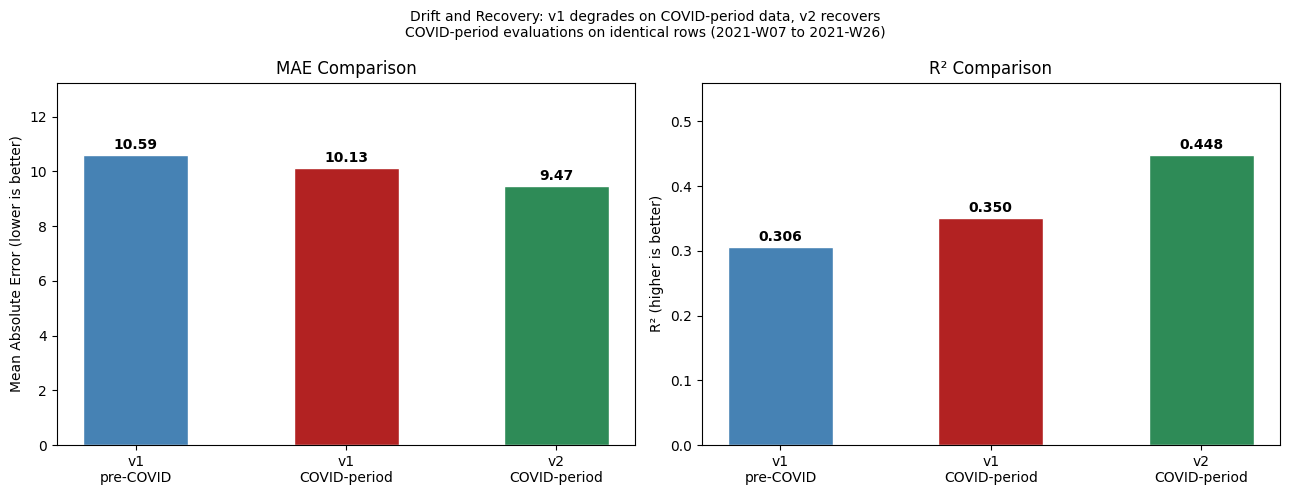

Saved: outputs/figures/model_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ["v1\npre-COVID", "v1\nCOVID-period", "v2\nCOVID-period"]
maes   = [V1_PRE_COVID_TEST_MAE, v1_covid_mae,  v2_covid_mae]
r2s    = [V1_PRE_COVID_TEST_R2,  v1_covid_r2,   v2_covid_r2]
colors = ["steelblue", "firebrick", "seagreen"]

# MAE chart
bars = axes[0].bar(labels, maes, color=colors, width=0.5, edgecolor="white")
axes[0].set_ylabel("Mean Absolute Error (lower is better)")
axes[0].set_title("MAE Comparison")
axes[0].set_ylim(0, max(maes) * 1.25)
for bar, mae in zip(bars, maes):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{mae:.2f}", ha="center", va="bottom", fontweight="bold"
    )

# R2 chart
axes[1].bar(labels, r2s, color=colors, width=0.5, edgecolor="white")
axes[1].set_ylabel("R² (higher is better)")
axes[1].set_title("R² Comparison")
axes[1].set_ylim(0, max(r2s) * 1.25)
for bar, r2 in zip(axes[1].patches, r2s):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{r2:.3f}", ha="center", va="bottom", fontweight="bold"
    )

plt.suptitle(
    "Drift and Recovery: v1 degrades on COVID-period data, v2 recovers\n"
    "COVID-period evaluations on identical rows (2021-W07 to 2021-W26)",
    fontsize=10
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/model_comparison.png")

In [12]:
comparison = pd.DataFrame({
    "model":      ["v1_pre_covid", "v1_covid_period", "v2_covid_period"],
    "period":     ["2019-W46/2020-W11", "2021-W07/2021-W26",
                   "2021-W07/2021-W26"],
    "features":   ["sensing_only", "sensing_only", "sensing_plus_covid"],
    "n_features": [len(SENSING_FEATURES), len(SENSING_FEATURES),
                   len(ALL_FEATURES)],
    "test_mae":   [V1_PRE_COVID_TEST_MAE, v1_covid_mae,  v2_covid_mae],
    "test_r2":    [V1_PRE_COVID_TEST_R2,  v1_covid_r2,   v2_covid_r2],
})

out_path = OUTPUT_DIR / "tables" / "model_comparison.csv"
comparison.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print()
print(comparison.to_string(index=False))

with mlflow.start_run(run_name="phase3_model_comparison"):
    mlflow.log_metrics({
        "v1_pre_covid_test_mae":    V1_PRE_COVID_TEST_MAE,
        "v1_covid_period_test_mae": v1_covid_mae,
        "v2_covid_period_test_mae": v2_covid_mae,
        "drift_mae_increase":       v1_covid_mae - V1_PRE_COVID_TEST_MAE,
        "recovery_mae_gain":        v1_covid_mae - v2_covid_mae,
    })
    mlflow.log_artifact(str(out_path))
    mlflow.log_artifact(
        str(OUTPUT_DIR / "figures" / "model_comparison.png")
    )
    mlflow.set_tag("notebook", "04_model_comparison")

Saved: ..\..\outputs\tables\model_comparison.csv

          model            period           features  n_features  test_mae  test_r2
   v1_pre_covid 2019-W46/2020-W11       sensing_only          22 10.593600 0.305800
v1_covid_period 2021-W07/2021-W26       sensing_only          22 10.131919 0.350439
v2_covid_period 2021-W07/2021-W26 sensing_plus_covid          32  9.474785 0.448143
🏃 View run phase3_model_comparison at: http://localhost:5000/#/experiments/2/runs/44ce5ea686324785bde58873f2ff5b13
🧪 View experiment at: http://localhost:5000/#/experiments/2
